In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/stray_animal_reports.csv")

df.head()

,Report_ID,Animal_Type,Breed,Age,Gender,Health_Status,Location,Reported_Date,Rescue_Status
0,1,Dog,Beagle,5,Male,Healthy,Negombo,2026-01-13,Rescued
1,2,Dog,Labrador,15,Female,Healthy,Galle,2026-01-28,Rescued
2,3,Cat,Domestic Short Hair,5,Male,Healthy,Colombo,2026-05-22,Rescued
3,4,Dog,Golden Retriever,1,Male,Critical,Jaffna,2026-04-29,Released
4,5,Dog,Beagle,5,Male,Sick,Colombo,2026-01-27,Under Treatment


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (1000, 9)

Columns:
['Report_ID', 'Animal_Type', 'Breed', 'Age', 'Gender', 'Health_Status', 'Location', 'Reported_Date', 'Rescue_Status']


In [4]:
X = df[['Animal_Type', 'Breed', 'Age', 'Gender', 'Location', 'Rescue_Status']]

y = df['Health_Status']

In [5]:
print(y.value_counts())

Health_Status
Sick        278
Injured     248
Healthy     239
Critical    235
Name: count, dtype: int64


In [6]:
categorical_features = [
    'Animal_Type',
    'Breed',
    'Gender',
    'Location',
    'Rescue_Status'
]

numerical_features = [
    'Age'
]

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', LabelEncoder(), categorical_features)
    ]
)

In [8]:
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [9]:
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print("Classes:")
print(target_encoder.classes_)

Classes:
['Critical' 'Healthy' 'Injured' 'Sick']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [12]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=target_encoder.classes_
    )
)

Random Forest Accuracy: 0.265

Classification Report:
              precision    recall  f1-score   support

    Critical       0.19      0.19      0.19        47
     Healthy       0.32      0.27      0.29        48
     Injured       0.27      0.24      0.26        50
        Sick       0.28      0.35      0.31        55

    accuracy                           0.27       200
   macro avg       0.27      0.26      0.26       200
weighted avg       0.27      0.27      0.26       200



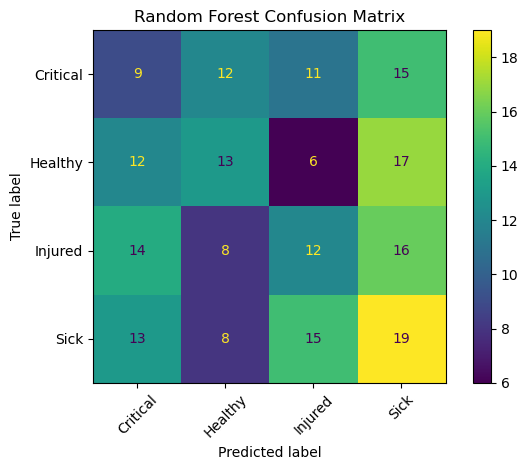

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=target_encoder.classes_,
    xticks_rotation=45
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))
    ]
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [15]:
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        dt_predictions,
        target_names=target_encoder.classes_
    )
)

Decision Tree Accuracy: 0.255

Classification Report:
              precision    recall  f1-score   support

    Critical       0.20      0.17      0.18        47
     Healthy       0.43      0.40      0.41        48
     Injured       0.20      0.34      0.25        50
        Sick       0.23      0.13      0.16        55

    accuracy                           0.26       200
   macro avg       0.26      0.26      0.25       200
weighted avg       0.26      0.26      0.25       200



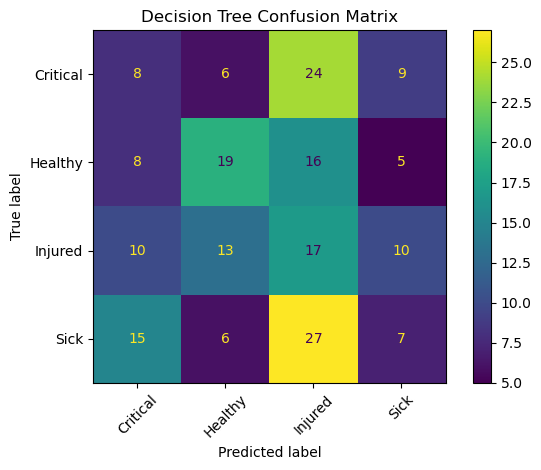

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_predictions,
    display_labels=target_encoder.classes_,
    xticks_rotation=45
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ]
)

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

In [18]:
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("KNN Accuracy:", knn_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        knn_predictions,
        target_names=target_encoder.classes_
    )
)

KNN Accuracy: 0.29

Classification Report:
              precision    recall  f1-score   support

    Critical       0.23      0.36      0.28        47
     Healthy       0.29      0.33      0.31        48
     Injured       0.29      0.20      0.24        50
        Sick       0.42      0.27      0.33        55

    accuracy                           0.29       200
   macro avg       0.31      0.29      0.29       200
weighted avg       0.31      0.29      0.29       200



In [19]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

In [20]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:", logistic_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=target_encoder.classes_
    )
)

Logistic Regression Accuracy: 0.2

Classification Report:
              precision    recall  f1-score   support

    Critical       0.16      0.17      0.16        47
     Healthy       0.26      0.23      0.24        48
     Injured       0.16      0.14      0.15        50
        Sick       0.23      0.25      0.24        55

    accuracy                           0.20       200
   macro avg       0.20      0.20      0.20       200
weighted avg       0.20      0.20      0.20       200



In [21]:
results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Decision Tree',
        'KNN',
        'Logistic Regression'
    ],
    'Accuracy': [
        rf_accuracy,
        dt_accuracy,
        knn_accuracy,
        logistic_accuracy
    ]
})

results

,Model,Accuracy
0,Random Forest,0.265
1,Decision Tree,0.255
2,KNN,0.290
3,Logistic Regression,0.200


In [22]:
results = results.sort_values(
    by='Accuracy',
    ascending=False
)

results

,Model,Accuracy
2,KNN,0.290
0,Random Forest,0.265
1,Decision Tree,0.255
3,Logistic Regression,0.200


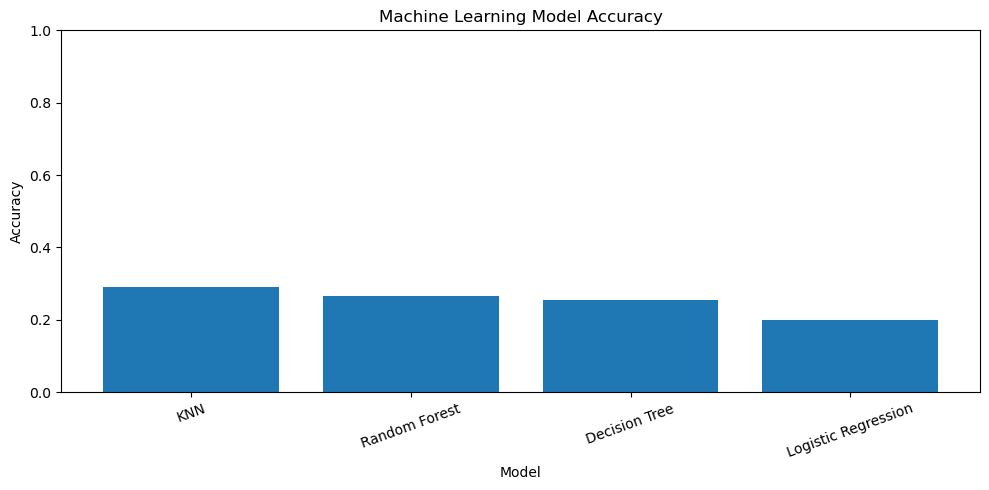

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    results['Model'],
    results['Accuracy']
)

plt.title("Machine Learning Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_data = df[
    ['Animal_Type', 'Age']
].copy()

cluster_data = pd.get_dummies(
    cluster_data,
    columns=['Animal_Type']
)

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

In [25]:
kmeans_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(
    cluster_scaled
)

df['KMeans_Cluster'] = kmeans_labels

df[['Animal_Type', 'Age', 'KMeans_Cluster']].head()

C:\Users\senay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,Animal_Type,Age,KMeans_Cluster
0,Dog,5,0
1,Dog,15,2
2,Cat,5,3
3,Dog,1,0
4,Dog,5,0


In [26]:
print(
    df['KMeans_Cluster'].value_counts().sort_index()
)

KMeans_Cluster
0    260
1    267
2    249
3    224
Name: count, dtype: int64


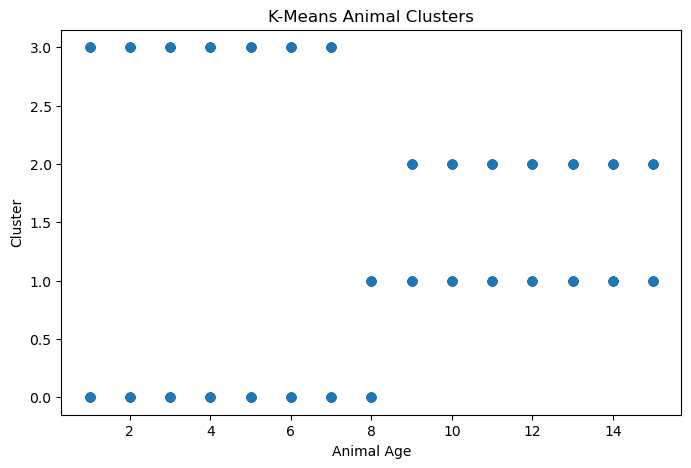

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Age'],
    df['KMeans_Cluster']
)

plt.xlabel("Animal Age")
plt.ylabel("Cluster")
plt.title("K-Means Animal Clusters")

plt.show()

In [28]:
print("===== MODEL COMPARISON =====")

print(
    f"Random Forest       : {rf_accuracy:.4f}"
)

print(
    f"Decision Tree       : {dt_accuracy:.4f}"
)

print(
    f"KNN                 : {knn_accuracy:.4f}"
)

print(
    f"Logistic Regression : {logistic_accuracy:.4f}"
)

===== MODEL COMPARISON =====
Random Forest       : 0.2650
Decision Tree       : 0.2550
KNN                 : 0.2900
Logistic Regression : 0.2000


In [29]:
best_model = results.iloc[0]

print(
    f"\nBest Model: {best_model['Model']}"
)

print(
    f"Accuracy: {best_model['Accuracy']:.4f}"
)


Best Model: KNN
Accuracy: 0.2900
